Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Acccuracy Metrics:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Correct predictions:  1.0
Wrong predictions:  0.0


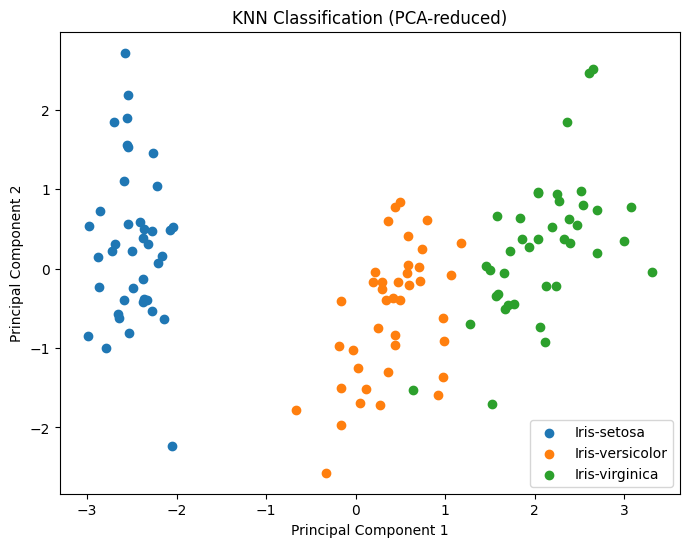

In [ ]:
#Implement KNN algorithm 

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
dataset = pd.read_csv('iris.csv')
x = dataset.iloc[:, :-1].to_numpy(dtype=float)
y = dataset.iloc[:, -1].astype(str).to_numpy()

x_train, x_test, y_train, y_test = train_test_split(
	x, y, test_size=0.2, random_state=0, stratify=y
)
classifier = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
classifier.fit(x_train, y_train)

#predict the test results
y_pred = classifier.predict(x_test)

cm=confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
print('Acccuracy Metrics:\n', classification_report(y_test, y_pred))
print("Correct predictions: ", accuracy_score(y_test, y_pred))
print("Wrong predictions: ", 1-accuracy_score(y_test, y_pred))

# visulatin of KNN
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Get target names from the dataset
target_names = dataset.iloc[:, -1].unique()

plt.figure(figsize=(8, 6))
for i, target_name in enumerate(target_names):
   indices = y_train == target_name
   plt.scatter(X_train_pca[indices, 0], X_train_pca[indices, 1], label=target_name)
plt.title("KNN Classification (PCA-reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

Accuracy: 0.93

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


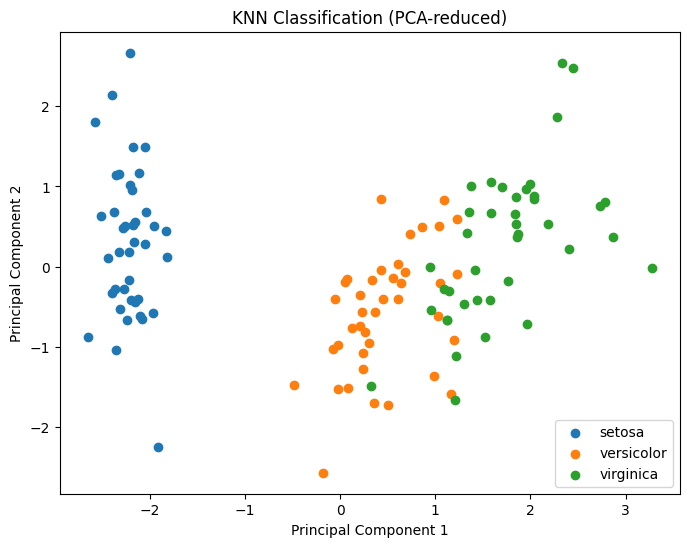

In [8]:
# KNN Classification Example using scikit-learn

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load dataset (Iris dataset for demo)
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Labels

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature scaling (important for distance-based algorithms like KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Create and train KNN model
k = 5  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='minkowski', p=2)
knn.fit(X_train_scaled, y_train)

# 5. Make predictions
y_pred = knn.predict(X_test_scaled)

# 6. Evaluate model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# For visualization (optional)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA   
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
plt.figure(figsize=(8, 6))
for i, target_name in enumerate(iris.target_names):
   plt.scatter(X_train_pca[y_train == i, 0], X_train_pca[y_train == i, 1], label=target_name)
plt.title("KNN Classification (PCA-reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
